In [36]:
from dotenv import load_dotenv
load_dotenv()

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

# Compton y calculation
from astropy.constants import k_B, m_p, c, sigma_T, m_e
from astropy import units as u

from astropy.coordinates import SkyCoord
import astropy.units as u

import utils as ut

# latex font
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=22)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
def calc_y_and_err(tau, tau_err, Te, Te_err):
    Te = Te * u.keV
    Te_err = Te_err * u.keV
    Te_K = (Te / k_B).to(u.K)    
    Te_err_K = (Te_err / k_B).to(u.K)

    y = tau * k_B * Te_K / (m_e * c**2).to(u.J)
    yerr = y * np.sqrt((tau_err / tau)**2 + (Te_err_K / Te_K)**2)

    return y.value, yerr.value

def get_y_vector(samples, idx_tau, idx_Te):
    Te = samples[:, idx_Te] * u.keV
    tau = samples[:, idx_tau]
    Te_K = (Te / k_B).to(u.K)
    y = tau * k_B * Te_K / (m_e * c**2).to(u.J)
    return y.value

def calc_mean_and_std(samples, idx):
    data = samples[:, idx]

    mcmc_run = np.percentile(data, [16, 50, 84])
    err = .5 * (mcmc_run[2] - mcmc_run[0])
    
    # Calculate bin width using Freedman-Diaconis rule
    n = len(data)
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    bin_width = 2 * iqr * n**(-1/3)

    # Calculate number of bins using bin width
    num_bins = int((np.max(data) - np.min(data)) / bin_width)

    # Create histogram
    hist, bin_edges = np.histogram(data, bins=num_bins, density=True)

    # Find bin with maximum value (estimate of mode)
    mode_bin = np.argmax(hist)
    mode_value = 0.5 * (bin_edges[mode_bin] + bin_edges[mode_bin + 1])

    mean = mode_value
    std = err
    return mean, std

In [12]:
# indices for the chain parameters
param_indices = {
    'ra_a401': 0,
    'dec_a401': 1,
    'beta_a401': 2,
    'rc_a401': 3,
    'R_a401': 4,
    'theta_a401': 5,
    'tau_a401': 6,
    'Te_a401': 7,
    'AD_a401': 8,
    "vc_a401": 9,

    'ra_a399': 10,
    'dec_a399': 11,
    'beta_a399': 12,
    'rc_a399': 13,
    'R_a399': 14,
    'theta_a399': 15,
    'tau_a399': 16,
    'Te_a399': 17,
    'AD_a399': 18,
    "vc_a399": 19,

    'fil_ra': 20,
    'fil_dec': 21,
    'fil_l0': 22,
    'fil_w0': 23,
    'tau_fil': 24,
    'Te_fil': 25,
    'fil_AD': 26,
    'fil_vavg': 27
}

case54 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case54/chain.h5"
case57 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case57/chain.h5"
case58 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case58/chain.h5"
case59 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case59/chain.h5"
case60 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case60/chain.h5"
case61 = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/case61/chain.h5"

In [13]:
burnin = 10000
thin = 1
samples_case54 = emcee.backends.HDFBackend(case54).get_chain(discard=burnin, flat=True, thin=thin)
samples_case57 = emcee.backends.HDFBackend(case57).get_chain(discard=burnin, flat=True, thin=thin)
samples_case58 = emcee.backends.HDFBackend(case58).get_chain(discard=burnin, flat=True, thin=thin)
samples_case59 = emcee.backends.HDFBackend(case59).get_chain(discard=burnin, flat=True, thin=thin)
samples_case60 = emcee.backends.HDFBackend(case60).get_chain(discard=burnin, flat=True, thin=thin)
samples_case61 = emcee.backends.HDFBackend(case61).get_chain(discard=burnin, flat=True, thin=thin)

print("Number of samples for case 54: {:.0f}".format(samples_case54.shape[0] / emcee.backends.HDFBackend(case54).shape[0]))
print("Number of iterations for case 57: {:.0f}".format(samples_case57.shape[0] / emcee.backends.HDFBackend(case57).shape[0]))
print("Number of iterations for case 58: {:.0f}".format(samples_case58.shape[0] / emcee.backends.HDFBackend(case58).shape[0]))
print("Number of iterations for case 59: {:.0f}".format(samples_case59.shape[0] / emcee.backends.HDFBackend(case59).shape[0]))
print("Number of iterations for case 60: {:.0f}".format(samples_case60.shape[0] / emcee.backends.HDFBackend(case60).shape[0]))
print("Number of iterations for case 61: {:.0f}".format(samples_case61.shape[0] / emcee.backends.HDFBackend(case61).shape[0]))

Number of samples for case 54: 120252
Number of iterations for case 57: 25548
Number of iterations for case 58: 25185
Number of iterations for case 59: 24183
Number of iterations for case 60: 23919
Number of iterations for case 61: 34111


In [14]:
cases = [
    (samples_case54, "case54"),
    (samples_case57, "case57"),
    (samples_case58, "case58"),
    (samples_case59, "case59"),
    (samples_case60, "case60"),
    (samples_case61, "case61")
]

case_labels = ["Temperature: X-ray", 
               r"5\% higher than X-ray", 
               r"10\% higher than X-ray", 
               r"15\% higher than X-ray", 
               r"20\% higher than X-ray", 
               r"25\% higher than X-ray",
]

In [15]:
# Compton y fits
# --- A401 ---
# Compton-y fit
compton_y_fits = {
    "ra_a401_mean": 44.751,
    "ra_a401_std": 0.002,
    "dec_a401_mean": 13.572,
    "dec_a401_std": 0.002,
    "beta_a401_mean": 0.82,
    "beta_a401_std": 0.05,
    "rc_a401_mean": 2.6,
    "rc_a401_std": 0.35,
    "R_a401_mean": 0.82,
    "R_a401_std": 0.055,
    "theta_a401_mean": 123,
    "theta_a401_std": 8.5,
    "y_a401_mean": 1.260e-04,
    "y_a401_std": 6.00e-06,
    
    "ra_a399_mean": 44.473,
    "ra_a399_std": 0.004,
    "dec_a399_mean": 13.03,
    "dec_a399_std": 0.003,
    "beta_a399_mean": 0.81,
    "beta_a399_std": 0.095,
    "rc_a399_mean": 3.0,
    "rc_a399_std": 0.65,
    "R_a399_mean": 0.93,
    "R_a399_std": 0.06,
    "theta_a399_mean": 133,
    "theta_a399_std": 26.5,
    "y_a399_mean": 8.100e-05,
    "y_a399_std": 6.00e-06,
    
    "fil_ra_mean": 44.68,
    "fil_ra_std": 0.02,
    "fil_dec_mean": 13.37,
    "fil_dec_std": 0.025,
    "fil_l0_mean": 12.3,
    "fil_l0_std": 1.55,
    "fil_w0_mean": 10.8,
    "fil_w0_std": 1.05,
    "y_fil_mean": 1.100e-05,
    "y_fil_std": 1.750e-06,
}

In [16]:
def result_comparer(samples, compton_y_fits, param_indices, cf_path):
    # create a dictionary of the sample results
    # create the labels first for the dictionary
    print("Working on config file path:", cf_path)
    ## Take care of RA and DEC values 
    cf = ut.get_config_file(f'{cf_path}')

    region = ut.get_region(cf['region_center_ra'], 
                           cf['region_center_dec'], 
                           cf['region_width'])

    dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
    data_ref = enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                              box=region)
    
    a401_ra_pix = samples[:, param_indices['ra_a401']]
    a401_dec_pix = samples[:, param_indices['dec_a401']]

    a399_ra_pix = samples[:, param_indices['ra_a399']]
    a399_dec_pix = samples[:, param_indices['dec_a399']]

    fil_ra_pix = samples[:, param_indices['fil_ra']]
    fil_dec_pix = samples[:, param_indices['fil_dec']]

    ra_a401, dec_a401 = data_ref.wcs.celestial.wcs_pix2world(a401_ra_pix, a401_dec_pix, 0)
    samples[:, param_indices['ra_a401']] = ra_a401
    samples[:, param_indices['dec_a401']] = dec_a401

    ra_a399, dec_a399 = data_ref.wcs.celestial.wcs_pix2world(a399_ra_pix, a399_dec_pix, 0)
    samples[:, param_indices['ra_a399']] = ra_a399
    samples[:, param_indices['dec_a399']] = dec_a399

    fil_ra, fil_dec = data_ref.wcs.celestial.wcs_pix2world(fil_ra_pix, fil_dec_pix, 0)
    samples[:, param_indices['fil_ra']] = fil_ra
    samples[:, param_indices['fil_dec']] = fil_dec

    samples[:, param_indices["fil_l0"]] *= 0.5
    samples[:, param_indices["fil_w0"]] *= 0.5

    samples[:, param_indices["R_a401"]] = 1 / samples[:, param_indices["R_a401"]]
    samples[:, param_indices["R_a399"]] = 1 / samples[:, param_indices["R_a399"]]
    
    # create a dictionary to hold the results
    labels = {
        "ra_a401_mean": 0,
        "ra_a401_std": 0,

        "dec_a401_mean": 0,
        "dec_a401_std": 0,

        "beta_a401_mean": 0,
        "beta_a401_std": 0,

        "rc_a401_mean": 0,
        "rc_a401_std": 0,

        "R_a401_mean": 0,
        "R_a401_std": 0,

        "theta_a401_mean": 0,
        "theta_a401_std": 0,

        "tau_a401_mean": 0,
        "tau_a401_std": 0,

        "Te_a401_mean": 0,
        "Te_a401_std": 0,

        "AD_a401_mean": 0,
        "AD_a401_std": 0,

        "ra_a399_mean": 0,
        "ra_a399_std": 0,

        "dec_a399_mean": 0,
        "dec_a399_std": 0,

        "beta_a399_mean": 0,
        "beta_a399_std": 0,

        "rc_a399_mean": 0,
        "rc_a399_std": 0,

        "R_a399_mean": 0,
        "R_a399_std": 0,

        "theta_a399_mean": 0,
        "theta_a399_std": 0,

        "tau_a399_mean": 0,
        "tau_a399_std": 0,

        "Te_a399_mean": 0,
        "Te_a399_std": 0,

        "AD_a399_mean": 0,
        "AD_a399_std": 0,

        "fil_ra_mean": 0,
        "fil_ra_std": 0,

        "fil_dec_mean": 0,
        "fil_dec_std": 0,

        "fil_l0_mean": 0,
        "fil_l0_std": 0,

        "fil_w0_mean": 0,
        "fil_w0_std": 0,

        "tau_fil_mean": 0,
        "tau_fil_std": 0,

        "Te_fil_mean": 0,
        "Te_fil_std": 0,

        "fil_AD_mean": 0,
        "fil_AD_std": 0,

        "fil_vavg_mean": 0,
        "fil_vavg_std": 0,

        "y_a401_mean": 0,
        "y_a401_std": 0,
        
        "y_a399_mean": 0,
        "y_a399_std": 0,

        "y_fil_mean": 0,
        "y_fil_std": 0,
    }

    # calculate the mean and std for each param in labels
    for key in labels.keys():
        if "std" in key:
            continue
        
        if "y_" in key:
            object_name = key.split('_')[1]
            Te = labels[f'Te_{object_name}_mean']
            Te_err = labels[f'Te_{object_name}_std']
            tau = labels[f'tau_{object_name}_mean']
            tau_err = labels[f'tau_{object_name}_std']
            y, yerr = calc_y_and_err(tau, tau_err, Te, Te_err)

            labels[key] = y
            labels[key.replace("mean", "std")] = yerr
        else:
            idx = param_indices[key.split('_')[0] + '_' + key.split('_')[1]]
            mean, std = calc_mean_and_std(samples, idx)
            labels[key] = mean
            labels[key.replace("mean", "std")] = std

    print("Results:")
    for key, value in labels.items():
        print(f"{key}: {value:.7f}")

    # for each parameter that is common between labels and compton_y_fits, compare the values 
    # and print the difference in standard deviations
    print("\nComparison with Compton y fits:")
    
    for key in labels.keys():
        if "mean" not in key:
            continue
        if key in compton_y_fits:
            diff = (labels[key] - compton_y_fits[key]) / (np.sqrt(labels[key.replace("mean", "std")]**2 + compton_y_fits[key.replace("mean", "std")]**2))
            print(f"{key}: {labels[key]:.7f} vs {compton_y_fits[key]:.7f} | Diff: {diff:.2f} σ")
        else:
            print(f"{key} not found in Compton y fits")

    a401_y_vector = get_y_vector(samples, param_indices['tau_a401'], param_indices['Te_a401'])
    a399_y_vector = get_y_vector(samples, param_indices['tau_a399'], param_indices['Te_a399'])
    fil_y_vector = get_y_vector(samples, param_indices['tau_fil'], param_indices['Te_fil'])

    return a401_y_vector, a399_y_vector, fil_y_vector

    # # Plot the y distributions
    # plt.figure(figsize=(15, 8))
    # plt.hist(a401_y_vector, bins=50, alpha=0.5, label='A401 y', density=True, histtype='stepfilled')
    # plt.hist(a399_y_vector, bins=50, alpha=0.5, label='A399 y', density=True, histtype='stepfilled')
    # plt.hist(fil_y_vector, bins=50, alpha=0.5, label='Filament y', density=True, histtype='stepfilled')

    # # plot the compton y- y paramter assuming a normal distribution (np.normal(loc=mean, scale=std))
    # plt.hist(np.random.normal(compton_y_fits['y_a401_mean'], compton_y_fits['y_a401_std'], 10000), 
    #          histtype='stepfilled',
    #          bins=50, alpha=0.5, label='A401 y (Compton fit)', density=True)
    # plt.hist(np.random.normal(compton_y_fits['y_a399_mean'], compton_y_fits['y_a399_std'], 10000),
    #             histtype='stepfilled',
    #          bins=50, alpha=0.5, label='A399 y (Compton fit)', density=True)
    # plt.hist(np.random.normal(compton_y_fits['y_fil_mean'], compton_y_fits['y_fil_std'], 10000),
    #             histtype='stepfilled',
    #          bins=50, alpha=0.5, label='Filament y (Compton fit)', density=True)
    
    # plt.xlabel('Compton y')
    # plt.ylabel('Density')
    # plt.title('Compton y Distributions')
    # plt.legend()
    # plt.show()

In [17]:
configs = [
    "/home/gill/research/ACT/multi-freq-bridge/configs/case54_ajay.yaml", 
    "/home/gill/research/ACT/multi-freq-bridge/configs/case57_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case58_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case59_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case60_ajay.yaml",
    "/home/gill/research/ACT/multi-freq-bridge/configs/case61_ajay.yaml",
]

a401_y_vector_case54, a399_y_vector_case54, fil_y_vector_case54 = result_comparer(samples_case54, compton_y_fits, param_indices, configs[0])
a401_y_vector_case57, a399_y_vector_case57, fil_y_vector_case57 = result_comparer(samples_case57, compton_y_fits, param_indices, configs[1])
a401_y_vector_case58, a399_y_vector_case58, fil_y_vector_case58 = result_comparer(samples_case58, compton_y_fits, param_indices, configs[2])
a401_y_vector_case59, a399_y_vector_case59, fil_y_vector_case59 = result_comparer(samples_case59, compton_y_fits, param_indices, configs[3])
a401_y_vector_case60, a399_y_vector_case60, fil_y_vector_case60 = result_comparer(samples_case60, compton_y_fits, param_indices, configs[4])
a401_y_vector_case61, a399_y_vector_case61, fil_y_vector_case61 = result_comparer(samples_case61, compton_y_fits, param_indices, configs[5])

Working on config file path: /home/gill/research/ACT/multi-freq-bridge/configs/case54_ajay.yaml
Results:
ra_a401_mean: 44.7412389
ra_a401_std: 0.0013876
dec_a401_mean: 13.5799182
dec_a401_std: 0.0018604
beta_a401_mean: 1.1069893
beta_a401_std: 0.0608872
rc_a401_mean: 4.3331676
rc_a401_std: 0.3938068
R_a401_mean: 0.7978266
R_a401_std: 0.0453534
theta_a401_mean: 107.0919450
theta_a401_std: 5.5865904
tau_a401_mean: 0.0073737
tau_a401_std: 0.0004152
Te_a401_mean: 8.4520865
Te_a401_std: 0.2487886
AD_a401_mean: 133645.0677185
AD_a401_std: 188296.7363971
ra_a399_mean: 44.4640132
ra_a399_std: 0.0027492
dec_a399_mean: 13.0400463
dec_a399_std: 0.0030002
beta_a399_mean: 1.1231192
beta_a399_std: 0.0941466
rc_a399_mean: 4.2324137
rc_a399_std: 0.5522604
R_a399_mean: 0.9309782
R_a399_std: 0.0817539
theta_a399_mean: 98.5872281
theta_a399_std: 30.7448365
tau_a399_mean: 0.0065561
tau_a399_std: 0.0004670
Te_a399_mean: 7.2344798
Te_a399_std: 0.1908730
AD_a399_mean: 1815.4205120
AD_a399_std: 101896.3123916

In [ ]:
a401_y_vector_case10, a399_y_vector_case10, fil_y_vector_case10 = result_comparer(samples_case10, compton_y_fits, param_indices, configs[0])


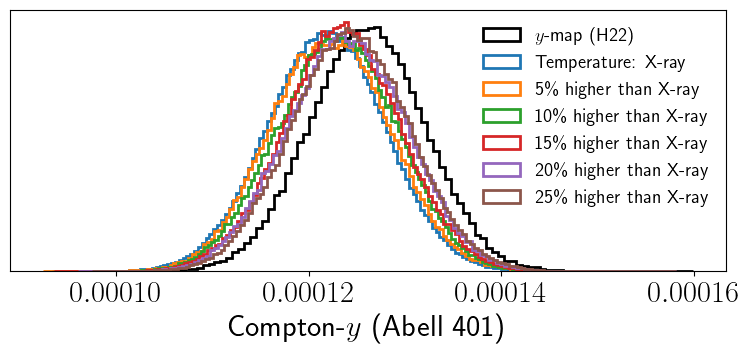

In [40]:
# plot the y distributions for each case - separate figures
# A401 Compton-y distributions
plt.figure(figsize=(8, 4))
plt.hist(np.random.normal(compton_y_fits['y_a401_mean'], compton_y_fits['y_a401_std'], 100000), 
         histtype='step', color='black', linestyle='-',
         bins=100, alpha=1, label='$y$-map (H22)', density=True, lw=2)
plt.hist(a401_y_vector_case54, bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(a401_y_vector_case57, bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(a401_y_vector_case58, bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(a401_y_vector_case59, bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(a401_y_vector_case60, bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(a401_y_vector_case61, bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Compton-$y$ (Abell 401)')
plt.legend(fontsize=13.5, frameon=False, loc="upper right")
plt.gca().set_yticks([])
# plt.title("Compton-$y$ vs temperature for individual velocity fits (Abell 401)", fontsize=18)
plt.tight_layout()
plt.savefig("../plots/y_Te_ind_vc_a401_sep15.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# # A399 Compton-y distributions
# plt.figure(figsize=(8, 4))
# plt.hist(np.random.normal(compton_y_fits['y_a399_mean'], compton_y_fits['y_a399_std'], 100000), 
#          histtype='step', 
#          bins=100, alpha=1, label='$y$-map (H22)', density=True, lw=2, color='black', linestyle='-')
# plt.hist(a399_y_vector_case10, bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
# plt.hist(a399_y_vector_case27, bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
# plt.hist(a399_y_vector_case28, bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
# plt.hist(a399_y_vector_case31, bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
# plt.hist(a399_y_vector_case32, bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
# plt.hist(a399_y_vector_case33, bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)
# plt.title("Compton-$y$ vs temperature for system velocity fits (Abell 399)", fontsize=16)

# plt.xlabel('Compton-$y$ (Abell 399)')
# plt.legend(fontsize=13, frameon=False, loc="upper left")
# plt.gca().set_yticks([])
# plt.tight_layout()
# # plt.xlim(0.00006, 0.00012)
# plt.savefig("../plots/y_Te_system_vc_a399.pdf", bbox_inches='tight', dpi=300, format='pdf')
# plt.show()

# # Filament Compton-y distributions
# plt.figure(figsize=(8, 4))
# plt.hist(np.random.normal(compton_y_fits['y_fil_mean'], compton_y_fits['y_fil_std'], 100000), 
#          histtype='step', 
#          bins=100, alpha=1, label='$y$-map (H22)', density=True, lw=2, color='black', linestyle='-')

# plt.hist(fil_y_vector_case10, bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
# plt.hist(fil_y_vector_case27, bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
# plt.hist(fil_y_vector_case28, bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
# plt.hist(fil_y_vector_case31, bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
# plt.hist(fil_y_vector_case32, bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
# plt.hist(fil_y_vector_case33, bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)
# plt.title("Compton-$y$ vs temperature for system velocity fits (filament)", fontsize=16)

# plt.xlabel('Compton-$y$ (Filament)')
# plt.legend(fontsize=13, frameon=False)
# plt.gca().set_yticks([])
# plt.tight_layout()
# plt.savefig("../plots/y_Te_system_vc_fil.pdf", bbox_inches='tight', dpi=300, format='pdf')
# plt.show()


In [ ]:
# Plot tau distributions for each case - separate figures
# A401 Tau distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case10[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case27[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case28[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case31[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case32[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case33[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Optical depth $\\tau$ (Abell 401)')
plt.legend(fontsize=13, frameon=False, loc="upper right")
plt.gca().set_yticks([])
plt.title("Optical depth vs temperature for system velocity fits (Abell 401)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/tau_Te_system_vc_a401.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# A399 Tau distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case10[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case27[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case28[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case31[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case32[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case33[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Optical depth $\\tau$ (Abell 399)')
plt.legend(fontsize=13, frameon=False, loc="upper right")
plt.gca().set_yticks([])
plt.title("Optical depth vs temperature for system velocity fits (Abell 399)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/tau_Te_system_vc_a399.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# Filament Tau distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case10[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case27[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case28[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case31[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case32[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case33[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Optical depth $\\tau$ (Filament)')
plt.legend(fontsize=13, frameon=False)
plt.gca().set_yticks([])
plt.title("Optical depth vs temperature for system velocity fits (filament)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/tau_Te_system_vc_fil.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

In [ ]:
# plot velocity distributions for each case on the same figure
plt.figure(figsize=(7, 4))
plt.hist(samples_case10[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case27[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case28[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case31[:, param_indices['fil_vavg']], bins=150, alpha= 1, label=case_labels[3], density=True, histtype='step', lw=2)   
plt.hist(samples_case32[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case33[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)
plt.xlabel('Cluster pair system velocity (km s$^{-1}$)')
plt.legend(fontsize=13, frameon=False)
plt.gca().set_yticks([])
plt.title("Cluster pair system velocity distributions vs temperature", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/fil_vavg_system_vc_vs_Te.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.xlim(-2000, 2000)
plt.show()

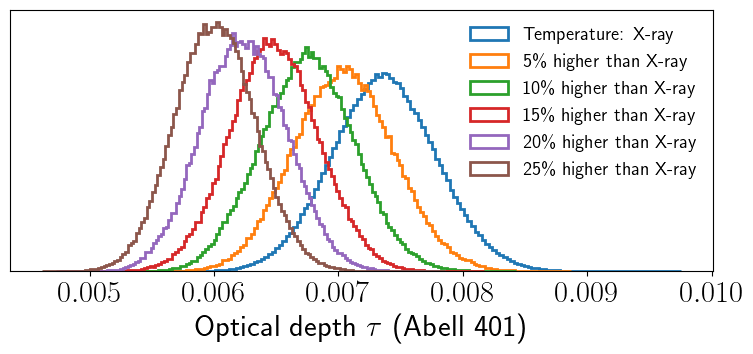

In [37]:
# velocity compare
# Plot tau distributions for each case - separate figures
# A401 Tau distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case54[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case57[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case58[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case59[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case60[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case61[:, param_indices['tau_a401']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Optical depth $\\tau$ (Abell 401)')
plt.legend(fontsize=13.5, frameon=False, loc="upper right")
plt.gca().set_yticks([])
# plt.title("Optical depth vs temperature for individual velocity fits (Abell 401)", fontsize=18)
plt.tight_layout()
plt.savefig("../plots/tau_Te_ind_vc_a401_sep14.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# # A399 Tau distributions
# plt.figure(figsize=(8, 4))
# plt.hist(samples_case23[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
# plt.hist(samples_case34[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
# plt.hist(samples_case35[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
# plt.hist(samples_case36[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
# plt.hist(samples_case37[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
# plt.hist(samples_case38[:, param_indices['tau_a399']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

# plt.xlabel('Optical depth $\\tau$ (Abell 399)')
# plt.legend(fontsize=13, frameon=False, loc="upper right")
# plt.gca().set_yticks([])
# plt.title("Optical depth vs temperature for individual velocity fits (Abell 399)", fontsize=16)
# plt.tight_layout()
# plt.savefig("../plots/tau_Te_ind_vc_a399.pdf", bbox_inches='tight', dpi=300, format='pdf')
# plt.show()

# # Filament Tau distributions
# plt.figure(figsize=(8, 4))
# plt.hist(samples_case23[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
# plt.hist(samples_case34[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
# plt.hist(samples_case35[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
# plt.hist(samples_case36[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
# plt.hist(samples_case37[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
# plt.hist(samples_case38[:, param_indices['tau_fil']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

# plt.xlabel('Optical depth $\\tau$ (Filament)')
# plt.legend(fontsize=13, frameon=False)
# plt.gca().set_yticks([])
# plt.title("Optical depth vs temperature for individual velocity fits (filament)", fontsize=16)
# plt.tight_layout()
# plt.savefig("../plots/tau_Te_ind_vc_fil.pdf", bbox_inches='tight', dpi=300, format='pdf')
# plt.show()

In [ ]:
# Plot velocity distributions for each case - separate figures
# A401 velocity distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case23[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Radial velocity (km/s) (Abell 401)')
plt.legend(fontsize=13, frameon=False, loc="upper right")
plt.gca().set_yticks([])
plt.title("Radial velocity vs temperature for individual velocity fits (Abell 401)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vr_Te_ind_vc_a401.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# A399 velocity distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case23[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Radial velocity (km/s) (Abell 399)')
plt.legend(fontsize=13, frameon=False, loc="upper right")
plt.gca().set_yticks([])
plt.title("Radial velocity vs temperature for individual velocity fits (Abell 399)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vr_Te_ind_vc_a399.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# Filament velocity distributions
plt.figure(figsize=(8, 4))
plt.hist(samples_case23[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Average velocity (km/s) (Filament)')
plt.legend(fontsize=13, frameon=False)
plt.gca().set_yticks([])
plt.title("Average velocity vs temperature for individual velocity fits (filament)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vavg_Te_ind_vc_fil.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()


In [ ]:
# Plot velocity distributions for each case - separate figures
# A401 velocity distributions
plt.figure(figsize=(7, 4))
plt.hist(samples_case23[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['vr_a401']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Velocity (km s$^{-1}$) (Abell 401)')
plt.legend(fontsize=14, frameon=False, loc="upper left")
plt.gca().set_yticks([])
plt.title("Velocity vs temperature for individual velocity fits (Abell 401)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vr_Te_ind_vc_a401.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# A399 velocity distributions
plt.figure(figsize=(7, 4))
plt.hist(samples_case23[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['vr_a399']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Velocity (km s$^{-1}$) (Abell 399)')
plt.legend(fontsize=14, frameon=False, loc="upper left")
plt.gca().set_yticks([])
plt.title("Velocity vs temperature for individual velocity fits (Abell 399)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vr_Te_ind_vc_a399.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

# Filament velocity distributions
plt.figure(figsize=(7, 4))
plt.hist(samples_case23[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[0], density=True, histtype='step', lw=2)
plt.hist(samples_case34[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[1], density=True, histtype='step', lw=2)
plt.hist(samples_case35[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[2], density=True, histtype='step', lw=2)
plt.hist(samples_case36[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[3], density=True, histtype='step', lw=2)
plt.hist(samples_case37[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[4], density=True, histtype='step', lw=2)
plt.hist(samples_case38[:, param_indices['fil_vavg']], bins=150, alpha=1, label=case_labels[5], density=True, histtype='step', lw=2)

plt.xlabel('Velocity (km s$^{-1}$) (Filament)')
plt.legend(fontsize=14, frameon=False)
plt.gca().set_yticks([])
plt.title("Velocity vs temperature for individual velocity fits (filament)", fontsize=16)
plt.tight_layout()
plt.savefig("../plots/vavg_Te_ind_vc_fil.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()


In [ ]:
# Te distributions for each case
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
plt.hist(samples_case24[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
plt.hist(samples_case25[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
plt.hist(samples_case26[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['Te_a401']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Temperature (keV)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("temperature_a401_distributions.png", bbox_inches='tight')
plt.show()
# Te distributions for A399
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
plt.hist(samples_case24[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
plt.hist(samples_case25[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
plt.hist(samples_case26[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)     
plt.hist(samples_case27[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['Te_a399']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Temperature (keV)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("temperature_a399_distributions.png", bbox_inches='tight')
plt.show()
# Te distributions for Filament
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)  
plt.hist(samples_case24[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
plt.hist(samples_case25[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
plt.hist(samples_case26[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['Te_fil']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Temperature (keV)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
#plt.savefig("temperature_filament_distributions.png", bbox_inches='tight')
plt.show()

In [ ]:
# tau histograms for a401   
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(samples_case24[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(samples_case25[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
# plt.hist(samples_case26[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)    
plt.hist(samples_case32[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['tau_a401']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Optical depth (A401)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
plt.xlim(0.004, 0.01)
#plt.savefig("tau_a401_distributions.png", bbox_inches='tight')
plt.show()

# tau histograms for a399
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(samples_case24[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(samples_case25[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)    
# plt.hist(samples_case26[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['tau_a399']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Optical depth (A399)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
plt.xlim(0.003, 0.008)
#plt.savefig("tau_a399_distributions.png", bbox_inches='tight')
plt.show()

# tau histograms for filament
plt.figure(figsize=(12, 5))
plt.hist(samples_case10[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[0], density=True, histtype='step', lw=3)
#plt.hist(samples_case24[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[1], density=True, histtype='step', lw=3)
#plt.hist(samples_case25[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[2], density=True, histtype='step', lw=3)
# plt.hist(samples_case26[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[3], density=True, histtype='step', lw=3)
plt.hist(samples_case27[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[4], density=True, histtype='step', lw=3)
plt.hist(samples_case28[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[5], density=True, histtype='step', lw=3)
plt.hist(samples_case29[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[6], density=True, histtype='step', lw=3)
plt.hist(samples_case30[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[7], density=True, histtype='step', lw=3)
plt.hist(samples_case31[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[8], density=True, histtype='step', lw=3)
plt.hist(samples_case32[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[9], density=True, histtype='step', lw=3)
plt.hist(samples_case33[:, param_indices['tau_fil']], bins=200, alpha=1, label=case_labels[10], density=True, histtype='step', lw=3)
plt.xlabel('Optical depth (Filament)')
plt.legend(fontsize=12)
plt.gca().set_yticks([])
plt.xlim(0.0005, 0.0017)
#plt.savefig("tau_filament_distributions.png", bbox_inches='tight')
plt.show()

In [ ]:
# plot the histograms of the temperature for each case with three subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# A401 temperatures
for i, (samples, case_name) in enumerate(cases):
    Te_a401 = samples[:, param_indices['Te_a401']]
    axes[0].hist(Te_a401, bins=50, alpha=0.7, label=f'{case_name}', density=True, histtype='step')
axes[0].set_xlabel('Temperature (keV)')
axes[0].set_ylabel('Density')
axes[0].set_title('A401 Temperature Distributions')
axes[0].legend()

# A399 temperatures
for i, (samples, case_name) in enumerate(cases):
    Te_a399 = samples[:, param_indices['Te_a399']]
    axes[1].hist(Te_a399, bins=50, alpha=0.7, label=f'{case_name}', density=True, histtype='step')
axes[1].set_xlabel('Temperature (keV)')
axes[1].set_ylabel('Density')
axes[1].set_title('A399 Temperature Distributions')
axes[1].legend()

# Filament temperatures
for i, (samples, case_name) in enumerate(cases):
    Te_fil = samples[:, param_indices['Te_fil']]
    axes[2].hist(Te_fil, bins=50, alpha=1, lw=3, label=f'{case_name}', density=True, histtype='step')
axes[2].set_xlabel('Temperature (keV)')
axes[2].set_ylabel('Density')
axes[2].set_title('Filament Temperature Distributions')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
cf = ut.get_config_file('/home/gill/research/ACT/multi-freq-bridge/configs/case10_ajay.yaml')
region = ut.get_region(cf['region_center_ra'], 
                        cf['region_center_dec'], 
                        cf['region_width'])

dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                            box=region))

plate_scale = 0.5
r500_a401 = plate_scale * ut.get_r500(mass=cf['c1_mass'], z=cf['c1_z']) * u.arcmin
r500_a399 = plate_scale * ut.get_r500(mass=cf['c2_mass'], z=cf['c2_z']) * u.arcmin

r_core_a401 = 4.5 * u.arcmin
r_core_a399 = 4.2 * u.arcmin

ra_center_a401 = cf["c1_ra"]
dec_center_a401 = cf["c1_dec"]
ra_center_a399 = cf["c2_ra"]
dec_center_a399 = cf["c2_dec"]

In [ ]:
from pixell import colorize
colorize.mpl_register("planck")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pixell import enmap, reproject
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

# latex font
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=22)

# ---- Read and Prepare Map ----
cf = ut.get_config_file('/home/gill/research/ACT/multi-freq-bridge/configs/case10_ajay.yaml')
region = ut.get_region(cf['region_center_ra'], cf['region_center_dec'], 1.*cf['region_width'])
dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"

data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", box=region))

# ---- Physical Parameters ----
plate_scale = 0.5  # arcmin/pixel

r500_a401 = plate_scale * ut.get_r500(mass=cf['c1_mass'], z=cf['c1_z']) * u.arcmin
r500_a399 = plate_scale * ut.get_r500(mass=cf['c2_mass'], z=cf['c2_z']) * u.arcmin

r_core_a401 = 4.5 * u.arcmin
r_core_a399 = 4.2 * u.arcmin

ra_center_a401 = cf["c1_ra"]
dec_center_a401 = cf["c1_dec"]
ra_center_a399 = cf["c2_ra"]
dec_center_a399 = cf["c2_dec"]

# ---- Setup WCS and Plot ----
wcs = data_ref.wcs
shape = data_ref.shape

fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(projection=(wcs))

im = ax.imshow(data_ref, origin='lower', cmap='planck')
ax.invert_xaxis()  # Invert x-axis for RA
plt.colorbar(im, ax=ax, orientation='vertical', label='$\mu$K')

def draw_circle(ax, ra, dec, radius, **kwargs):
    """Draw a circle at (ra, dec) with radius in arcmin."""
    center = SkyCoord(ra*u.deg, dec*u.deg)
    theta = np.linspace(0, 2*np.pi, 200)
    offset = radius.to(u.deg).value
    ras = center.ra.deg + offset * np.cos(theta) / np.cos(np.deg2rad(center.dec.deg))
    decs = center.dec.deg + offset * np.sin(theta)
    ax.plot(ras, decs, transform=ax.get_transform('world'), **kwargs)

# ---- Draw circles ----
draw_circle(ax, ra_center_a401, dec_center_a401, r500_a401, color='black', lw=2, ls='-',label='$R_{500c}$ (A401)')
draw_circle(ax, ra_center_a401, dec_center_a401, r_core_a401, color='black', lw=1, ls='--', label=r'$R_{\rm core}$ (A401)')
draw_circle(ax, ra_center_a399, dec_center_a399, r500_a399, color='red', lw=2, ls='-',label='$R_{500c}$ (A399)')
draw_circle(ax, ra_center_a399, dec_center_a399, r_core_a399, color='red', lw=1, ls='--', label=r'$R_{\rm core}$ (A399)')

# ---- Plot Formatting ----
ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.legend(loc='upper right', fontsize=14, facecolor='white', edgecolor='black', framealpha=1.0)

# add a text box with white background towards the bottom center of the plot saying "ACT PA5 f90"
textstr = 'ACT PA5 (90 GHz)'
props = dict(boxstyle='round', facecolor='white', alpha=1)
ax.text(0.5, 0.05, textstr, transform=ax.transAxes, fontsize=15,
        verticalalignment='center', horizontalalignment='center', bbox=props)
plt.tight_layout()
plt.savefig("../plots/map_r500_core.pdf", dpi=300, bbox_inches='tight')
plt.show()
